In [206]:
import pandas as pd 
import os
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [207]:
mm = pd.read_excel('/Users/taliacho/Downloads/Ranger Lab/Bryan-Ranger/body_comp/US_data_1.29.24.xlsx')
mm['BM'] = mm[['B1M', 'B2M', 'B3M']].mean(axis=1,skipna=True)
mm['BA'] = mm[['B1A', 'B2A', 'B3A']].mean(axis=1,skipna=True)
mm['AA'] = mm[['A1A', 'A2A', 'A3A']].mean(axis=1,skipna=True)
mm['AM'] = mm[['A1M', 'A2M', 'A3M']].mean(axis=1,skipna=True)
mm['QA'] = mm[['Q1A', 'Q2A', 'Q3A']].mean(axis=1,skipna=True)
mm['QM'] = mm[['Q1M', 'Q2M', 'Q3M']].mean(axis=1,skipna=True)

mm_avg = mm[['Study ID','BM','BA','AM','AA','QM','QA']]

In [208]:
hp = pd.read_excel('/Users/taliacho/Downloads/Ranger Lab/Bryan-Ranger/body_comp/Data_11.5.23.xlsx')
hp_check = hp[['Study_ID','PerFM','PerFFM']]
hp_avg = hp[['PerFM','PerFFM']]

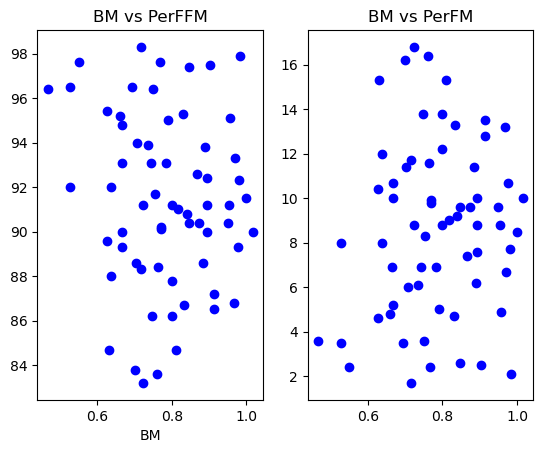

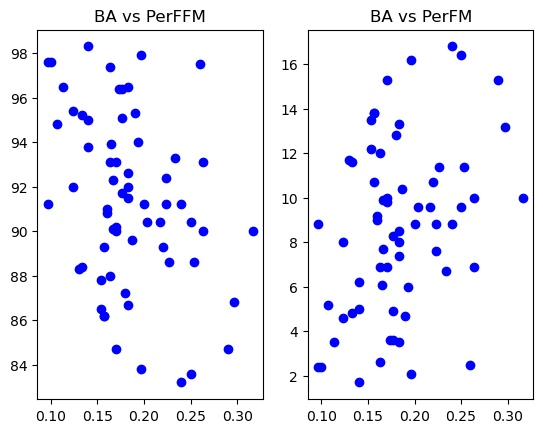

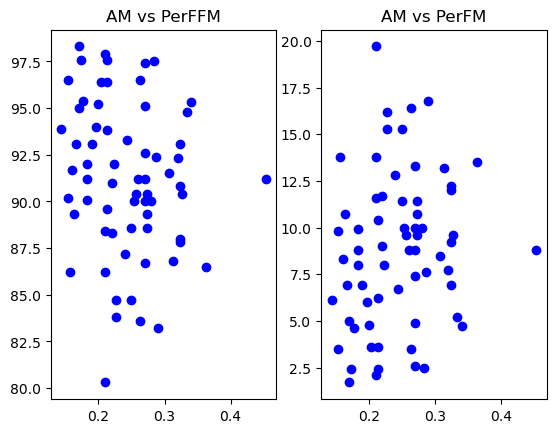

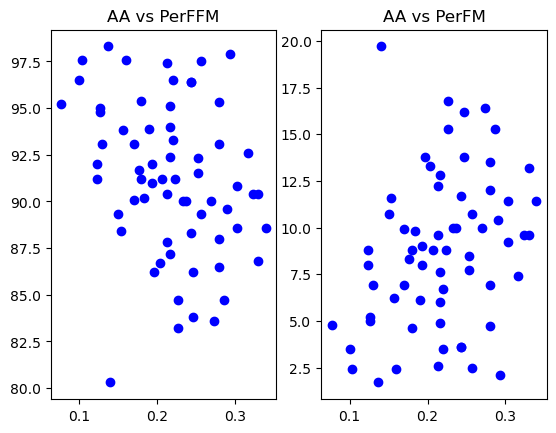

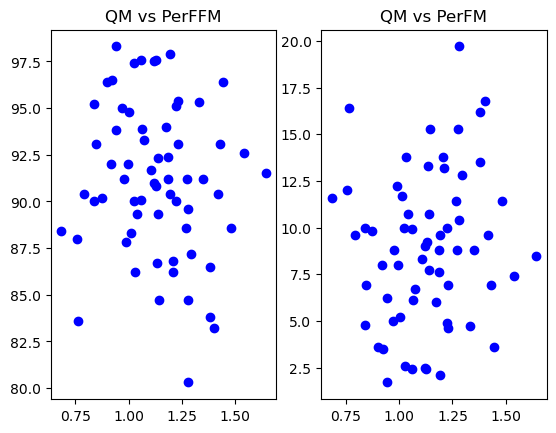

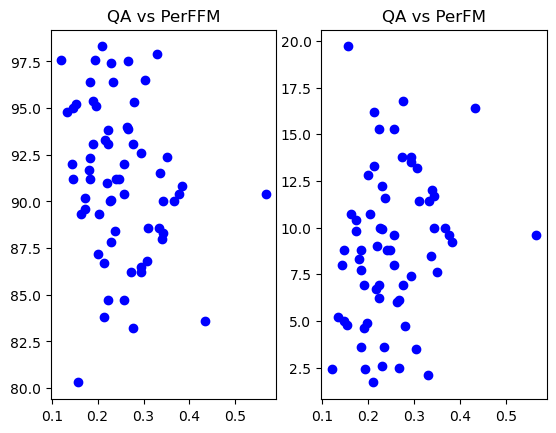

In [209]:
df = pd.concat([mm_avg, hp_avg], axis=1)
plt.subplot(1, 2, 1)
plt.plot(df['BM'], df['PerFFM'], marker='o',linestyle= "",color='b')
plt.title('BM vs PerFFM')
plt.xlabel('BM')
plt.subplot(1, 2, 2)
plt.plot(df['BM'], df['PerFM'], marker='o',linestyle= "",color='b')
plt.title('BM vs PerFM')
plt.show()

plt.subplot(1, 2, 1)
plt.plot(df['BA'], df['PerFFM'], marker='o',linestyle= "",color='b')
plt.title('BA vs PerFFM')
plt.subplot(1, 2, 2)
plt.plot(df['BA'], df['PerFM'], marker='o',linestyle= "",color='b')
plt.title('BA vs PerFM')
plt.show()

plt.subplot(1, 2, 1)
plt.plot(df['AM'], df['PerFFM'], marker='o',linestyle= "",color='b')
plt.title('AM vs PerFFM')
plt.subplot(1, 2, 2)
plt.plot(df['AM'], df['PerFM'], marker='o',linestyle= "",color='b')
plt.title('AM vs PerFM')
plt.show()

plt.subplot(1, 2, 1)
plt.plot(df['AA'], df['PerFFM'], marker='o',linestyle= "",color='b')
plt.title('AA vs PerFFM')
plt.subplot(1, 2, 2)
plt.plot(df['AA'], df['PerFM'], marker='o',linestyle= "",color='b')
plt.title('AA vs PerFM')
plt.show()

plt.subplot(1, 2, 1)
plt.plot(df['QM'], df['PerFFM'], marker='o',linestyle= "",color='b')
plt.title('QM vs PerFFM')
plt.subplot(1, 2, 2)
plt.plot(df['QM'], df['PerFM'], marker='o',linestyle= "",color='b')
plt.title('QM vs PerFM')
plt.show()

plt.subplot(1, 2, 1)
plt.plot(df['QA'], df['PerFFM'], marker='o',linestyle= "",color='b')
plt.title('QA vs PerFFM')
plt.subplot(1, 2, 2)
plt.plot(df['QA'], df['PerFM'], marker='o',linestyle= "",color='b')
plt.title('QA vs PerFM')
plt.show()

In [210]:
def split_data(data,train_size=0.8,test_size=0.1,random_state=None): #diff  outcomes for each run
    train,temp=train_test_split(data,train_size=train_size,random_state=random_state)
    test_and_valid_size = 1.0-train_size
    test_ratio = test_size/test_and_valid_size
    test,valid = train_test_split(temp,test_size=test_ratio,random_state=random_state)
    return train, test, valid

In [211]:
train, test, valid = split_data(df)

In [212]:
#Simple GPR to predict PerFM 
import math
import torch
import gpytorch
from matplotlib import pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [213]:
import torch

train_x = train['BA']
train_y = train['PerFM']

test_x = test['BA']
test_y = test['PerFM']

train_x = torch.tensor(train_x.to_numpy(), dtype=torch.float32)
train_y = torch.tensor(train_y.to_numpy(), dtype=torch.float32)

test_x = torch.tensor(test_x.to_numpy(), dtype=torch.float32) 
test_y = torch.tensor(test_y.to_numpy(), dtype=torch.float32) 

In [214]:
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# initialize likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x, train_y, likelihood)

In [215]:
# this is for running the notebook in our testing framework
import os
smoke_test = ('CI' in os.environ)
training_iter = 2 if smoke_test else 50

# Find optimal model hyperparameters
model.train()
likelihood.train()

# Use the adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)  # Includes GaussianLikelihood parameters

# "Loss" for GPs - the marginal log likelihood
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

for i in range(training_iter):
    # Zero gradients from previous iteration
    optimizer.zero_grad()
    # Output from model
    output = model(train_x)
    # Calc loss and backprop gradients
    loss = -mll(output, train_y)
    loss.backward()
    print('Iter %d/%d - Loss: %.3f   lengthscale: %.3f   noise: %.3f' % (
        i + 1, training_iter, loss.item(),
        model.covar_module.base_kernel.lengthscale.item(),
        model.likelihood.noise.item()
    ))
    optimizer.step()

Iter 1/50 - Loss: 11.946   lengthscale: 0.693   noise: 0.693
Iter 2/50 - Loss: 11.178   lengthscale: 0.644   noise: 0.744
Iter 3/50 - Loss: 10.483   lengthscale: 0.598   noise: 0.798
Iter 4/50 - Loss: 9.856   lengthscale: 0.554   noise: 0.854
Iter 5/50 - Loss: 9.291   lengthscale: 0.513   noise: 0.911
Iter 6/50 - Loss: 8.781   lengthscale: 0.474   noise: 0.970
Iter 7/50 - Loss: 8.323   lengthscale: 0.437   noise: 1.031
Iter 8/50 - Loss: 7.910   lengthscale: 0.403   noise: 1.092
Iter 9/50 - Loss: 7.538   lengthscale: 0.370   noise: 1.155
Iter 10/50 - Loss: 7.203   lengthscale: 0.341   noise: 1.218
Iter 11/50 - Loss: 6.902   lengthscale: 0.313   noise: 1.281
Iter 12/50 - Loss: 6.631   lengthscale: 0.287   noise: 1.345
Iter 13/50 - Loss: 6.387   lengthscale: 0.264   noise: 1.408
Iter 14/50 - Loss: 6.168   lengthscale: 0.243   noise: 1.471
Iter 15/50 - Loss: 5.971   lengthscale: 0.224   noise: 1.534
Iter 16/50 - Loss: 5.794   lengthscale: 0.207   noise: 1.596
Iter 17/50 - Loss: 5.634   len

In [216]:
import torch
from sklearn.metrics import mean_squared_error
from math import sqrt

model.eval()
likelihood.eval()

f_preds = model(test_x)
y_preds = likelihood(model(test_x))

f_mean = f_preds.mean
print(f_mean.size())
print(test_y.size())
f_var = f_preds.variance
f_covar = f_preds.covariance_matrix

rmse = sqrt(mean_squared_error(test_y.numpy(), f_mean.detach().numpy()))
print(rmse)


torch.Size([6])
torch.Size([6])
4.520878781326075


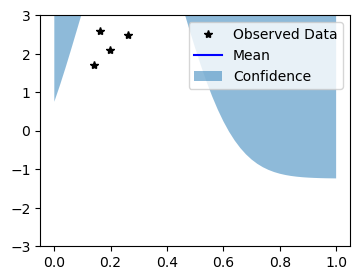

In [217]:
# Test points are regularly spaced along [0,1]
# Make predictions by feeding model through likelihood
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    test_x = torch.linspace(0, 1, 51)
    observed_pred = likelihood(model(test_x))

with torch.no_grad():
    # Initialize plot
    f, ax = plt.subplots(1, 1, figsize=(4, 3))

    # Get upper and lower confidence bounds
    lower, upper = observed_pred.confidence_region()
    # Plot training data as black stars
    ax.plot(train_x.numpy(), train_y.numpy(), 'k*')
    # Plot predictive means as blue line
    ax.plot(test_x.numpy(), observed_pred.mean.numpy(), 'b')
    # Shade between the lower and upper confidence bounds
    ax.fill_between(test_x.numpy(), lower.numpy(), upper.numpy(), alpha=0.5)
    ax.set_ylim([-3, 3])
    ax.legend(['Observed Data', 'Mean', 'Confidence'])